This marks the start of final year project made by students of department of Information Technology at GCET. The names of students are as follows:
- Mohd Meesam Raza 2200970130066
- Arunav Kumar Singh 2200970130027
- Animesh Kumar Rai 2200970130015
- Under guidance of: Dr. Jawed Miya, Faculty, IT Dept.

    

# Date Ingestion:

In [4]:
import os
print(os.listdir('../input'))

try:
    import google.generativeai
    import fpdf
except ImportError:
    !pip install -q google-generativeai fpdf

['chest-xrays-indiana-university']
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 22.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.6 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatibl

In [5]:
import pandas as pd
import os
import logging
from pathlib import Path
from typing import Optional, Tuple
import numpy as np
from typing import Any
# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# --- CONFIGURATION ---
BASE_PATH = '/kaggle/input/chest-xrays-indiana-university'
IMAGES_DIR = os.path.join(BASE_PATH, 'images', 'images_normalized')
REPORTS_CSV = os.path.join(BASE_PATH, 'indiana_reports.csv')
PROJECTIONS_CSV = os.path.join(BASE_PATH, 'indiana_projections.csv')
OUTPUT_CSV = '/kaggle/working/iu_xray_dataset.csv'

# Data quality thresholds
MIN_REPORT_LENGTH = 10
VALID_PROJECTIONS = {'Frontal', 'AP', 'PA', 'Lateral'}


def validate_paths() -> None:
    """
    Validate that all required paths exist.
    
    Raises:
        FileNotFoundError: If any required file or directory is missing
    """
    missing_files = []
    
    if not os.path.exists(REPORTS_CSV):
        missing_files.append(REPORTS_CSV)
    if not os.path.exists(PROJECTIONS_CSV):
        missing_files.append(PROJECTIONS_CSV)
    if not os.path.exists(IMAGES_DIR):
        missing_files.append(IMAGES_DIR)
    
    if missing_files:
        raise FileNotFoundError(
            f"Missing required files/directories:\n" + 
            "\n".join(f"  - {f}" for f in missing_files)
        )


def load_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load reports and projections CSVs.
    
    Returns:
        Tuple of (reports_df, projections_df)
        
    Raises:
        Exception: If CSV loading fails
    """
    logger.info("Loading raw CSVs...")
    
    try:
        df_reports = pd.read_csv(REPORTS_CSV)
        df_proj = pd.read_csv(PROJECTIONS_CSV)
        
        logger.info(f"  Reports: {len(df_reports)} rows")
        logger.info(f"  Projections: {len(df_proj)} rows")
        
        return df_reports, df_proj
        
    except Exception as e:
        logger.error(f"Failed to load CSV files: {e}")
        raise


def clean_text_field(text: Any) -> str:
    """
    Clean and normalize text fields.
    
    Args:
        text: Input text (may be string, float, or None)
        
    Returns:
        Cleaned string
    """
    if pd.isna(text) or text is None:
        return ""
    
    text_str = str(text).strip()
    
    # Handle various null representations
    if text_str.lower() in {'nan', 'none', 'null', ''}:
        return ""
    
    return text_str


def build_report_text(findings: str, impression: str) -> str:
    """
    Combine findings and impression into formatted report text.
    
    Args:
        findings: Findings section text
        impression: Impression section text
        
    Returns:
        Formatted report text
    """
    parts = []
    
    if findings:
        parts.append(f"FINDINGS: {findings}")
    if impression:
        parts.append(f"IMPRESSION: {impression}")
    
    return " ".join(parts)


def validate_report(report_text: str) -> bool:
    """
    Check if report meets quality criteria.
    
    Args:
        report_text: The report text to validate
        
    Returns:
        True if report is valid, False otherwise
    """
    return len(report_text) >= MIN_REPORT_LENGTH


def process_merged_data(df_merged: pd.DataFrame) -> list:
    """
    Process merged dataframe and create structured data rows.
    
    Args:
        df_merged: Merged dataframe with reports and projections
        
    Returns:
        List of data dictionaries
    """
    logger.info("Processing and validating data...")
    
    data_rows = []
    skipped_empty = 0
    skipped_missing_image = 0
    skipped_invalid = 0
    valid_images = set(os.listdir(IMAGES_DIR))
    for idx, row in df_merged.iterrows():
        # Clean text fields
        findings = clean_text_field(row.get('findings', ''))
        impression = clean_text_field(row.get('impression', ''))
        
        # Skip if both fields are empty
        if not findings and not impression:
            skipped_empty += 1
            continue
        
        # Build report text
        full_report = build_report_text(findings, impression)
        
        # Validate report quality
        if not validate_report(full_report):
            skipped_invalid += 1
            continue
        
        # Build and validate image path
        img_filename = row.get('filename', '')
        if not img_filename:
            skipped_missing_image += 1
            continue
            
        img_path = os.path.join(IMAGES_DIR, img_filename)
        
        # Check if image actually exists
        if img_filename not in valid_images:
            skipped_missing_image += 1
            continue
        
        # Extract and clean additional fields
        projection = str(row.get('projection', 'Frontal')).strip()
        mesh_tags = clean_text_field(row.get('MeSH', ''))
        
        data_rows.append({
            'uid': row['uid'],
            'image_id': Path(img_filename).stem.replace('.dcm', ''),  # Filename without extension
            'image_path': img_path,
            'report': full_report,
            'mesh_tags': mesh_tags,
            'findings': findings,
            'impression': impression,
            'projection': projection,
            'has_findings': bool(findings),
            'has_impression': bool(impression),
            'report_length': len(full_report)
        })
    
    # Log statistics
    logger.info(f"  Valid pairs: {len(data_rows)}")
    if skipped_empty > 0:
        logger.info(f"  Skipped (empty reports): {skipped_empty}")
    if skipped_invalid > 0:
        logger.info(f"  Skipped (too short): {skipped_invalid}")
    if skipped_missing_image > 0:
        logger.warning(f"  Skipped (missing images): {skipped_missing_image}")
    
    return data_rows


def generate_statistics(df: pd.DataFrame) -> None:
    """
    Generate and log dataset statistics.
    
    Args:
        df: The final dataset dataframe
    """
    logger.info("\n" + "="*50)
    logger.info("DATASET STATISTICS")
    logger.info("="*50)
    
    logger.info(f"Total image-report pairs: {len(df)}")
    logger.info(f"Unique UIDs: {df['uid'].nunique()}")
    logger.info(f"Unique images: {df['image_id'].nunique()}")
    
    # Report content statistics
    logger.info(f"\nReport Content:")
    logger.info(f"  With findings: {df['has_findings'].sum()} ({df['has_findings'].mean()*100:.1f}%)")
    logger.info(f"  With impression: {df['has_impression'].sum()} ({df['has_impression'].mean()*100:.1f}%)")
    logger.info(f"  Avg report length: {df['report_length'].mean():.0f} characters")
    
    # Projection distribution
    if 'projection' in df.columns:
        logger.info(f"\nProjection Distribution:")
        proj_counts = df['projection'].value_counts()
        for proj, count in proj_counts.items():
            logger.info(f"  {proj}: {count} ({count/len(df)*100:.1f}%)")
    
    # MeSH tags statistics
    if 'mesh_tags' in df.columns:
        non_empty_mesh = df['mesh_tags'].astype(bool).sum()
        logger.info(f"\nMeSH Tags:")
        logger.info(f"  Reports with tags: {non_empty_mesh} ({non_empty_mesh/len(df)*100:.1f}%)")
    
    logger.info("="*50 + "\n")


def prepare_dataset() -> pd.DataFrame:
    """
    Main function to prepare the dataset.
    
    Returns:
        Final processed dataframe
        
    Raises:
        Exception: If dataset preparation fails
    """
    try:
        # Validate paths
        validate_paths()
        
        # Load data
        df_reports, df_proj = load_data()
        
        # Merge reports with projections
        logger.info("Merging reports with image metadata...")
        df_merged = pd.merge(
            df_reports, 
            df_proj, 
            on='uid', 
            how='inner'
        )
        logger.info(f"  Merged: {len(df_merged)} rows")
        
        # Process data
        data_rows = process_merged_data(df_merged)
        
        if not data_rows:
            raise ValueError("No valid data pairs were created. Check data quality and image paths.")
        
        # Create final dataframe
        final_df = pd.DataFrame(data_rows)
        
        # Save to CSV
        logger.info(f"Saving dataset to {OUTPUT_CSV}...")
        final_df.to_csv(OUTPUT_CSV, index=False)
        
        # Generate statistics
        generate_statistics(final_df)
        
        logger.info(f"✅ Dataset successfully saved to: {OUTPUT_CSV}")
        
        return final_df
        
    except Exception as e:
        logger.error(f"❌ Dataset preparation failed: {e}")
        raise


def main():
    """Main execution function."""
    try:
        df = prepare_dataset()
        
        # Display sample data
        print("\n" + "="*80)
        print("SAMPLE DATA (First 3 rows)")
        print("="*80)
        
        # Show selected columns for readability
        sample_cols = ['image_id', 'projection', 'report_length', 'report']
        sample_df = df[sample_cols].head(3)
        
        for idx, row in sample_df.iterrows():
            print(f"\n[{idx+1}] Image: {row['image_id']} | Projection: {row['projection']}")
            print(f"    Length: {row['report_length']} chars")
            # Truncate long reports for display
            report_preview = row['report'][:200] + "..." if len(row['report']) > 200 else row['report']
            print(f"    Report: {report_preview}")
        
        print("\n" + "="*80)
        
    except Exception as e:
        logger.error(f"Execution failed: {e}")
        raise


if __name__ == "__main__":
    main()

14:21:34 - INFO: Loading raw CSVs...
14:21:34 - INFO:   Reports: 3851 rows
14:21:34 - INFO:   Projections: 7466 rows
14:21:34 - INFO: Merging reports with image metadata...
14:21:34 - INFO:   Merged: 7466 rows
14:21:34 - INFO: Processing and validating data...
14:21:34 - INFO:   Valid pairs: 7426
14:21:34 - INFO:   Skipped (empty reports): 40
14:21:34 - INFO: Saving dataset to /kaggle/working/iu_xray_dataset.csv...
14:21:35 - INFO: 
14:21:35 - INFO: DATASET STATISTICS
14:21:35 - INFO: ==================================================
14:21:35 - INFO: Total image-report pairs: 7426
14:21:35 - INFO: Unique UIDs: 3826
14:21:35 - INFO: Unique images: 7426
14:21:35 - INFO: 
Report Content:
14:21:35 - INFO:   With findings: 6469 (87.1%)
14:21:35 - INFO:   With impression: 7414 (99.8%)
14:21:35 - INFO:   Avg report length: 289 characters
14:21:35 - INFO: 
Projection Distribution:
14:21:35 - INFO:   Frontal: 3794 (51.1%)
14:21:35 - INFO:   Lateral: 3632 (48.9%)
14:21:35 - INFO: 
MeSH Tags:
14


SAMPLE DATA (First 3 rows)

[1] Image: 1_IM-0001-4001 | Projection: Frontal
    Length: 253 chars
    Report: FINDINGS: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evide...

[2] Image: 1_IM-0001-3001 | Projection: Lateral
    Length: 253 chars
    Report: FINDINGS: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evide...

[3] Image: 2_IM-0652-1001 | Projection: Frontal
    Length: 167 chars
    Report: FINDINGS: Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX. IMPRESSION: No acute pulmonary findings.



# Data Pre-Processing


In [6]:
import os
import logging
from pathlib import Path
from typing import Tuple, Optional, List, Dict
from collections import Counter

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import nltk
import pickle

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# Download tokenizer resource
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

# --- CONFIGURATION ---
CSV_PATH = '/kaggle/working/iu_xray_dataset.csv'
VOCAB_PATH = '/kaggle/working/vocab.pkl'
DATASET_STATS_PATH = '/kaggle/working/dataset_stats.pkl'

BATCH_SIZE = 8
IMAGE_SIZE = 224  # Standard for DenseNet/ResNet
MAX_SEQ_LEN = 100
MIN_WORD_FREQ = 3
TOP_K_DISEASES = 14

# ImageNet normalization stats (standard for pretrained models)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


# --- 1. VOCABULARY CLASS ---
class Vocabulary:
    """
    Vocabulary class for text tokenization and encoding.
    """
    
    # Special tokens
    PAD_TOKEN = '<pad>'
    START_TOKEN = '<start>'
    END_TOKEN = '<end>'
    UNK_TOKEN = '<unk>'
    
    def __init__(self):
        self.word2idx: Dict[str, int] = {}
        self.idx2word: Dict[int, str] = {}
        self.word_freq: Counter = Counter()
        
        # Initialize with special tokens
        self._add_word(self.PAD_TOKEN)    # 0: Padding
        self._add_word(self.START_TOKEN)  # 1: Start of sequence
        self._add_word(self.END_TOKEN)    # 2: End of sequence
        self._add_word(self.UNK_TOKEN)    # 3: Unknown word

    def _add_word(self, word: str) -> None:
        """Add a word to the vocabulary."""
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def add_word(self, word: str, freq: int = 1) -> None:
        """
        Add a word to the vocabulary with its frequency.
        
        Args:
            word: Word to add
            freq: Frequency count of the word
        """
        self._add_word(word)
        self.word_freq[word] = freq

    def __call__(self, word: str) -> int:
        """Get index for a word, returning UNK index if not found."""
        return self.word2idx.get(word, self.word2idx[self.UNK_TOKEN])

    def __len__(self) -> int:
        """Return vocabulary size."""
        return len(self.word2idx)
    
    def decode(self, indices: List[int], skip_special: bool = True) -> str:
        """
        Convert indices back to text.
        
        Args:
            indices: List of word indices
            skip_special: Whether to skip special tokens
            
        Returns:
            Decoded text string
        """
        special_tokens = {self.PAD_TOKEN, self.START_TOKEN, self.END_TOKEN}
        words = []
        
        for idx in indices:
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            if skip_special and word in special_tokens:
                continue
            if word == self.END_TOKEN:
                break
            words.append(word)
        
        return ' '.join(words)
    
    def get_stats(self) -> Dict:
        """Return vocabulary statistics."""
        return {
            'total_words': len(self),
            'special_tokens': 4,
            'regular_words': len(self) - 4,
            'most_common': self.word_freq.most_common(10)
        }


def tokenize_text(text: str) -> List[str]:
    """
    Tokenize and clean text.
    
    Args:
        text: Input text string
        
    Returns:
        List of cleaned tokens
    """
    text = str(text).lower().strip()
    
    # Basic cleaning
    text = text.replace('\n', ' ').replace('\r', ' ')
    
    try:
        tokens = nltk.tokenize.word_tokenize(text)
    except Exception as e:
        logger.warning(f"Tokenization failed, using split(): {e}")
        tokens = text.split()
    
    # Filter out empty tokens
    tokens = [t.strip() for t in tokens if t.strip()]
    
    return tokens


def build_vocab(df: pd.DataFrame, threshold: int = MIN_WORD_FREQ) -> Vocabulary:
    """
    Build vocabulary from dataset.
    
    Args:
        df: DataFrame containing reports
        threshold: Minimum word frequency to include
        
    Returns:
        Vocabulary object
    """
    logger.info("Building vocabulary from dataset...")
    
    word_counter = Counter()
    total_reports = len(df)
    
    # Count words
    for idx, text in enumerate(df['report'], 1):
        if idx % 500 == 0:
            logger.info(f"  Processing report {idx}/{total_reports}")
        
        tokens = tokenize_text(text)
        word_counter.update(tokens)
    
    # Create vocabulary
    vocab = Vocabulary()
    
    # Add words meeting threshold
    words_added = 0
    for word, count in word_counter.items():
        if count >= threshold:
            vocab.add_word(word, count)
            words_added += 1
    
    logger.info(f"✅ Vocabulary built!")
    logger.info(f"  Total unique words: {len(word_counter)}")
    logger.info(f"  Words meeting threshold (>={threshold}): {words_added}")
    logger.info(f"  Final vocab size: {len(vocab)} (including special tokens)")
    
    return vocab


def extract_disease_labels(df: pd.DataFrame, top_k: int = TOP_K_DISEASES) -> Tuple[List[str], Dict[str, int]]:
    """
    Extract top-K disease labels from MeSH tags.
    
    Args:
        df: DataFrame containing mesh_tags column
        top_k: Number of top diseases to track
        
    Returns:
        Tuple of (disease_list, disease_to_idx_mapping)
    """
    logger.info(f"Extracting top-{top_k} disease labels...")
    
    disease_counter = Counter()
    
    for tags in df['mesh_tags'].fillna(''):
        tags_str = str(tags).lower().strip()
        
        if tags_str and tags_str != 'nan':
            # Handle multiple delimiters
            parts = tags_str.replace('|', ',').replace(';', ',').split(',')
            cleaned_tags = [p.strip() for p in parts if p.strip()]
            disease_counter.update(cleaned_tags)
    
    # Get top-K diseases
    top_diseases = [disease for disease, _ in disease_counter.most_common(top_k)]
    disease_to_idx = {disease: idx for idx, disease in enumerate(top_diseases)}
    
    logger.info(f"✅ Disease labels extracted:")
    logger.info(f"  Total unique diseases: {len(disease_counter)}")
    logger.info(f"  Top-{top_k} diseases: {top_diseases[:5]}... (showing first 5)")
    
    return top_diseases, disease_to_idx


# --- 2. DATASET CLASS ---
class MedicalReportDataset(Dataset):
    """
    PyTorch Dataset for medical images with report text and disease labels.
    """
    
    def __init__(
        self,
        csv_path: str,
        vocab: Vocabulary,
        disease_classes: List[str],
        disease_to_idx: Dict[str, int],
        transform: Optional[transforms.Compose] = None,
        max_seq_len: int = MAX_SEQ_LEN,
        return_metadata: bool = False
    ):
        """
        Initialize dataset.
        
        Args:
            csv_path: Path to dataset CSV
            vocab: Vocabulary object
            disease_classes: List of disease class names
            disease_to_idx: Mapping from disease name to index
            transform: Image transformations
            max_seq_len: Maximum sequence length for text
            return_metadata: Whether to return additional metadata
        """
        self.df = pd.read_csv(csv_path)
        self.vocab = vocab
        self.transform = transform
        self.max_seq_len = max_seq_len
        self.return_metadata = return_metadata
        
        self.disease_classes = disease_classes
        self.disease_to_idx = disease_to_idx
        
        logger.info(f"Dataset initialized with {len(self)} samples")

    def __len__(self) -> int:
        return len(self.df)

    def _load_image(self, img_path: str) -> Image.Image:
        """
        Load and validate image.
        
        Args:
            img_path: Path to image file
            
        Returns:
            PIL Image in RGB format
        """
        try:
            image = Image.open(img_path).convert('RGB')
            return image
        except Exception as e:
            logger.warning(f"Failed to load image {img_path}: {e}. Using blank image.")
            # Return blank image as fallback
            return Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color=(128, 128, 128))

    def _tokenize_report(self, report: str) -> torch.Tensor:
        """
        Tokenize and encode report text.
        
        Args:
            report: Report text string
            
        Returns:
            Tensor of token indices
        """
        tokens = tokenize_text(report)
        
        # Build token sequence
        token_indices = [self.vocab(Vocabulary.START_TOKEN)]
        token_indices.extend([self.vocab(token) for token in tokens])
        token_indices.append(self.vocab(Vocabulary.END_TOKEN))
        
        # Truncate if too long
        if len(token_indices) > self.max_seq_len:
            token_indices = token_indices[:self.max_seq_len - 1]
            token_indices.append(self.vocab(Vocabulary.END_TOKEN))
        
        # Pad if too short
        padding_length = self.max_seq_len - len(token_indices)
        if padding_length > 0:
            token_indices.extend([self.vocab(Vocabulary.PAD_TOKEN)] * padding_length)
        
        return torch.tensor(token_indices, dtype=torch.long)

    def _encode_diseases(self, mesh_tags: str) -> torch.Tensor:
        """
        Encode disease labels as multi-hot vector.
        
        Args:
            mesh_tags: String containing disease tags
            
        Returns:
            Multi-hot encoded tensor
        """
        label_vec = torch.zeros(len(self.disease_classes), dtype=torch.float32)
        
        tags_str = str(mesh_tags).lower().strip()
        if tags_str and tags_str != 'nan':
            parts = tags_str.replace('|', ',').replace(';', ',').split(',')
            cleaned_tags = [p.strip() for p in parts if p.strip()]
            
            for tag in cleaned_tags:
                if tag in self.disease_to_idx:
                    label_vec[self.disease_to_idx[tag]] = 1.0
        
        return label_vec

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Get a single data sample.
        
        Args:
            idx: Sample index
            
        Returns:
            Tuple of (image, caption_tokens, disease_labels) or with metadata
        """
        row = self.df.iloc[idx]
        
        # Load and transform image
        image = self._load_image(row['image_path'])
        if self.transform:
            image = self.transform(image)
        
        # Tokenize report
        caption = self._tokenize_report(row['report'])
        
        # Encode diseases
        labels = self._encode_diseases(row['mesh_tags'])
        
        if self.return_metadata:
            metadata = {
                'image_id': row.get('image_id', ''),
                'uid': row.get('uid', ''),
                'projection': row.get('projection', ''),
                'report_text': row['report']
            }
            return image, caption, labels, metadata
        
        return image, caption, labels


def get_transforms(augment: bool = False) -> transforms.Compose:
    """
    Get image transformation pipeline.
    
    Args:
        augment: Whether to include data augmentation
        
    Returns:
        Composed transforms
    """
    if augment:
        transform_list = [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ]
    else:
        transform_list = [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ]
    
    return transforms.Compose(transform_list)


def save_dataset_artifacts(vocab: Vocabulary, disease_classes: List[str], 
                           disease_to_idx: Dict[str, int]) -> None:
    """
    Save vocabulary and dataset statistics.
    
    Args:
        vocab: Vocabulary object
        disease_classes: List of disease class names
        disease_to_idx: Disease to index mapping
    """
    # Save vocabulary
    with open(VOCAB_PATH, 'wb') as f:
        pickle.dump(vocab, f)
    logger.info(f"✅ Vocabulary saved to {VOCAB_PATH}")
    
    # Save dataset statistics
    stats = {
        'vocab_size': len(vocab),
        'vocab_stats': vocab.get_stats(),
        'disease_classes': disease_classes,
        'disease_to_idx': disease_to_idx,
        'num_diseases': len(disease_classes),
        'max_seq_len': MAX_SEQ_LEN,
        'image_size': IMAGE_SIZE
    }
    
    with open(DATASET_STATS_PATH, 'wb') as f:
        pickle.dump(stats, f)
    logger.info(f"✅ Dataset stats saved to {DATASET_STATS_PATH}")


def load_dataset_artifacts() -> Tuple[Vocabulary, List[str], Dict[str, int]]:
    """
    Load saved vocabulary and dataset statistics.
    
    Returns:
        Tuple of (vocab, disease_classes, disease_to_idx)
    """
    with open(VOCAB_PATH, 'rb') as f:
        vocab = pickle.load(f)
    
    with open(DATASET_STATS_PATH, 'rb') as f:
        stats = pickle.load(f)
    
    return vocab, stats['disease_classes'], stats['disease_to_idx']


def test_dataloader(dataloader: DataLoader, vocab: Vocabulary) -> None:
    """
    Test the dataloader and print sample information.
    
    Args:
        dataloader: DataLoader to test
        vocab: Vocabulary for decoding
    """
    logger.info("\n" + "="*60)
    logger.info("DATALOADER TEST")
    logger.info("="*60)
    
    data_iter = iter(dataloader)
    images, captions, labels = next(data_iter)
    
    logger.info(f"✅ Batch loaded successfully!")
    logger.info(f"  Image batch shape: {images.shape} (Batch, C, H, W)")
    logger.info(f"  Caption batch shape: {captions.shape} (Batch, SeqLen)")
    logger.info(f"  Label batch shape: {labels.shape} (Batch, NumDiseases)")
    
    # Show sample
    logger.info(f"\nSample from batch:")
    logger.info(f"  Image range: [{images[0].min():.3f}, {images[0].max():.3f}]")
    logger.info(f"  Caption length: {(captions[0] != 0).sum().item()} tokens")
    logger.info(f"  Active diseases: {labels[0].sum().item():.0f}")
    logger.info(f"  Decoded text: {vocab.decode(captions[0].tolist())[:100]}...")
    
    logger.info("="*60 + "\n")


def main():
    """Main execution function."""
    try:
        # Validate CSV exists
        if not os.path.exists(CSV_PATH):
            raise FileNotFoundError(
                f"Dataset CSV not found at {CSV_PATH}. Run data preparation first."
            )
        
        logger.info("Loading dataset CSV...")
        df = pd.read_csv(CSV_PATH)
        logger.info(f"  Loaded {len(df)} samples")
        
        # Build vocabulary
        vocab = build_vocab(df, threshold=MIN_WORD_FREQ)
        
        # Extract disease labels
        disease_classes, disease_to_idx = extract_disease_labels(df, top_k=TOP_K_DISEASES)
        
        # Save artifacts
        save_dataset_artifacts(vocab, disease_classes, disease_to_idx)
        
        # Create dataset and dataloader
        logger.info("\nInitializing dataset and dataloader...")
        transform = get_transforms(augment=False)
        
        dataset = MedicalReportDataset(
            csv_path=CSV_PATH,
            vocab=vocab,
            disease_classes=disease_classes,
            disease_to_idx=disease_to_idx,
            transform=transform
        )
        
        dataloader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
        
        # Test dataloader
        test_dataloader(dataloader, vocab)
        
        logger.info("✅ All setup complete! Ready for training.")
        
    except Exception as e:
        logger.error(f"❌ Setup failed: {e}")
        raise


if __name__ == '__main__':
    main()

14:21:49 - INFO: Loading dataset CSV...
14:21:49 - INFO:   Loaded 7426 samples
14:21:49 - INFO: Building vocabulary from dataset...
14:21:49 - INFO:   Processing report 500/7426
14:21:49 - INFO:   Processing report 1000/7426
14:21:50 - INFO:   Processing report 1500/7426
14:21:50 - INFO:   Processing report 2000/7426
14:21:50 - INFO:   Processing report 2500/7426
14:21:50 - INFO:   Processing report 3000/7426
14:21:50 - INFO:   Processing report 3500/7426
14:21:51 - INFO:   Processing report 4000/7426
14:21:51 - INFO:   Processing report 4500/7426
14:21:51 - INFO:   Processing report 5000/7426
14:21:51 - INFO:   Processing report 5500/7426
14:21:52 - INFO:   Processing report 6000/7426
14:21:52 - INFO:   Processing report 6500/7426
14:21:52 - INFO:   Processing report 7000/7426
14:21:52 - INFO: ✅ Vocabulary built!
14:21:52 - INFO:   Total unique words: 2206
14:21:52 - INFO:   Words meeting threshold (>=3): 1549
14:21:52 - INFO:   Final vocab size: 1553 (including special tokens)
14:21:

# Data Validation

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import pickle
import logging
from typing import Tuple, Optional, Dict
from torchvision.models import DenseNet121_Weights

# ---------------- LOGGING ----------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# ---------------- CONFIG ----------------
STATS_PATH = '/kaggle/working/dataset_stats.pkl'

EMBED_DIM = 512
HIDDEN_DIM = 512
ATTENTION_DIM = 512
ENCODER_DIM = 1024
ENCODED_IMAGE_SIZE = 7
DROPOUT = 0.3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ---------------- LOAD CONFIG ----------------
def load_model_config(stats_path: str = STATS_PATH) -> Dict:
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)

    config = {
        'vocab_size': stats['vocab_size'],
        'num_diseases': stats['num_diseases']
    }

    logger.info(f"Vocab: {config['vocab_size']} | Diseases: {config['num_diseases']}")
    return config


# ---------------- ENCODER ----------------
class DenseNetEncoder(nn.Module):
    def __init__(self, fine_tune=False):
        super().__init__()

        densenet = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        self.pool = nn.AdaptiveAvgPool2d((ENCODED_IMAGE_SIZE, ENCODED_IMAGE_SIZE))

        self._set_fine_tune(fine_tune)

    def _set_fine_tune(self, fine_tune):
        for param in self.features.parameters():
            param.requires_grad = False

        if fine_tune:
            for name, param in self.features.named_parameters():
                if "denseblock4" in name or "norm5" in name:
                    param.requires_grad = True
            logger.info("Fine-tuning last DenseBlock")

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)

        b = x.size(0)
        x = x.permute(0, 2, 3, 1).view(b, -1, ENCODER_DIM)  # [B,49,1024]
        return x


# ---------------- CLASSIFIER ----------------
class DiseaseClassifier(nn.Module):
    def __init__(self, num_diseases):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(ENCODER_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, num_diseases)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool(x).squeeze(2)

        # 🔥 Added regularization
        x = F.dropout(x, p=0.3, training=self.training)

        logits = self.fc(x)
        return logits, x


# ---------------- ATTENTION ----------------
class Attention(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc_att = nn.Linear(ENCODER_DIM, ATTENTION_DIM)
        self.dec_att = nn.Linear(HIDDEN_DIM, ATTENTION_DIM)
        self.full = nn.Linear(ATTENTION_DIM, 1)

    def forward(self, enc_out, hidden):
        att1 = self.enc_att(enc_out)
        att2 = self.dec_att(hidden)

        att = self.full(torch.relu(att1 + att2.unsqueeze(1)))

        # 🔥 Stable softmax
        alpha = F.softmax(att / 1.5, dim=1)
        alpha = torch.clamp(alpha, min=1e-8)

        context = (enc_out * alpha).sum(dim=1)
        return context, alpha


# ---------------- DECODER ----------------
class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.dropout = nn.Dropout(DROPOUT)

        self.attention = Attention()

        self.lstm = nn.LSTMCell(EMBED_DIM + ENCODER_DIM + ENCODER_DIM, HIDDEN_DIM)

        self.init_h = nn.Linear(ENCODER_DIM, HIDDEN_DIM)
        self.init_c = nn.Linear(ENCODER_DIM, HIDDEN_DIM)

        self.f_beta = nn.Linear(HIDDEN_DIM, ENCODER_DIM)

        self.fc = nn.Linear(HIDDEN_DIM, vocab_size)

        # 🔥 Weight tying
        self.fc.weight = self.embedding.weight

    def init_hidden(self, enc_out):
        mean = enc_out.mean(dim=1)
        mean = F.layer_norm(mean, mean.shape[1:])  # 🔥 stability

        h = self.init_h(mean)
        c = self.init_c(mean)
        return h, c

    def forward(self, enc_out, global_feat, captions):
        b, seq_len = captions.size()

        embeddings = self.dropout(self.embedding(captions))

        h, c = self.init_hidden(enc_out)

        outputs = torch.zeros(b, seq_len, self.fc.out_features).to(enc_out.device)
        alphas = torch.zeros(b, seq_len, enc_out.size(1)).to(enc_out.device)

        for t in range(seq_len):
            context, alpha = self.attention(enc_out, h)

            gate = torch.sigmoid(self.f_beta(h))
            context = gate * context

            lstm_input = torch.cat([embeddings[:, t], context, global_feat], dim=1)

            h, c = self.lstm(lstm_input, (h, c))

            out = self.fc(self.dropout(h))
            out = torch.clamp(out, -10, 10)  # 🔥 stabilize

            outputs[:, t] = out
            alphas[:, t] = alpha.squeeze(2)

        return outputs, alphas


# ---------------- FULL MODEL ----------------
class MedicalReportModel(nn.Module):
    def __init__(self, vocab_size, num_diseases, fine_tune_encoder=False):
        super().__init__()

        self.encoder = DenseNetEncoder(fine_tune=fine_tune_encoder)
        self.classifier = DiseaseClassifier(num_diseases)
        self.decoder = Decoder(vocab_size)

        logger.info("Model initialized")

    def forward(self, images, captions):
        assert images.dim() == 4, "Images must be [B,3,H,W]"

        enc = self.encoder(images)
        logits, global_feat = self.classifier(enc)
        reports, alphas = self.decoder(enc, global_feat, captions)

        return reports, logits, alphas


# ---------------- FACTORY ----------------
def create_model(config: Optional[Dict] = None, fine_tune_encoder=False) -> MedicalReportModel:
    if config is None:
        config = load_model_config()

    model = MedicalReportModel(
        vocab_size=config['vocab_size'],
        num_diseases=config['num_diseases'],
        fine_tune_encoder=fine_tune_encoder  # ✅ NOW ACCEPTED
    )

    return model.to(DEVICE)


# ---------------- SANITY CHECK ----------------
def sanity_check():
    model = create_model()
    model.eval()

    x = torch.randn(2, 3, 224, 224).to(DEVICE)
    y = torch.randint(0, 1000, (2, 100)).to(DEVICE)

    with torch.no_grad():
        out, logits, alpha = model(x, y)

    print("✅ Shapes OK:", out.shape, logits.shape, alpha.shape)


if __name__ == "__main__":
    sanity_check()

14:22:00 - INFO: Vocab: 1553 | Diseases: 14
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 215MB/s]
14:22:01 - INFO: Model initialized


✅ Shapes OK: torch.Size([2, 100, 1553]) torch.Size([2, 14]) torch.Size([2, 100, 49])


# Model Building

In [8]:
from torch.utils.data import DataLoader, random_split

# --- LOAD ARTIFACTS ---
import pickle

with open('/kaggle/working/vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

with open('/kaggle/working/dataset_stats.pkl', 'rb') as f:
    stats = pickle.load(f)

# --- DATASET ---
transform = get_transforms(augment=True)

full_dataset = MedicalReportDataset(
    csv_path='/kaggle/working/iu_xray_dataset.csv',
    vocab=vocab,
    disease_classes=stats['disease_classes'],
    disease_to_idx=stats['disease_to_idx'],
    transform=transform
)

# --- TRAIN / VAL SPLIT ---
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# --- DATALOADERS ---
dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ Dataloaders ready")

14:22:10 - INFO: Dataset initialized with 7426 samples


Train: 6683 | Val: 743
✅ Dataloaders ready


14:22:15 - INFO: 🚀 Using cuda
14:22:15 - INFO: Vocab: 1553 | Diseases: 14
14:22:15 - INFO: Fine-tuning last DenseBlock
14:22:15 - INFO: Model initialized


Epoch 1:   0%|          | 0/418 [00:00<?, ?it/s]

14:27:55 - INFO: Epoch 1 | Train: 3.6771 | Val: 2.4620 | LR: 4.00e-04 | 341s


Epoch 2:   0%|          | 0/418 [00:00<?, ?it/s]

14:32:32 - INFO: Epoch 2 | Train: 2.5650 | Val: 2.1707 | LR: 4.00e-04 | 276s


...

14:59:52 - INFO: Epoch 8 | Train: 1.8080 | Val: 1.6673 | LR: 4.00e-04 | 270s


Epoch 9:   0%|          | 0/418 [00:00<?, ?it/s]

15:04:20 - INFO: Epoch 9 | Train: 1.7399 | Val: 1.6262 | LR: 4.00e-04 | 268s


Epoch 10:   0%|          | 0/418 [00:00<?, ?it/s]

15:08:46 - INFO: Epoch 10 | Train: 1.6891 | Val: 1.5933 | LR: 4.00e-04 | 266s


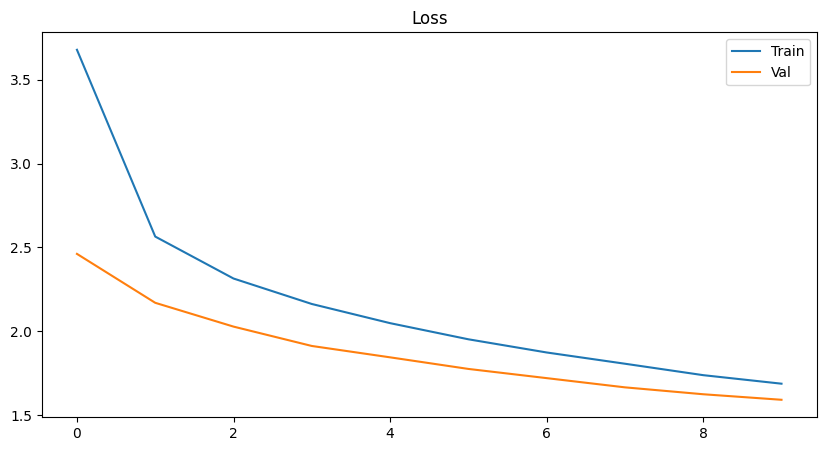

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
import time
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import logging
import numpy as np
from collections import defaultdict
import gc

# ---------------- LOGGING ----------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# ---------------- CONFIG ----------------
class Config:
    NUM_EPOCHS = 10
    LEARNING_RATE = 4e-4
    CLASSIFIER_WEIGHT = 1.0   # ✅ FIXED (important)
    GRAD_CLIP = 5.0

    SAVE_DIR = Path('/kaggle/working')
    BEST_MODEL_PATH = SAVE_DIR / 'best_model.pth'
    CHECKPOINT_PATH = SAVE_DIR / 'checkpoint.pth'

    PATIENCE = 3
    MIN_DELTA = 1e-4

    USE_SCHEDULER = True
    SCHEDULER_TYPE = 'plateau'  # or 'cosine'

    USE_AMP = True


# ---------------- EARLY STOPPING ----------------
class EarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        if score < self.best_score - self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            logger.info("⚠️ Early stopping triggered")
            return True

        return False


# ---------------- METRICS ----------------
class MetricsTracker:
    def __init__(self):
        self.metrics = defaultdict(list)

    def update(self, **kwargs):
        for k, v in kwargs.items():
            self.metrics[k].append(v)

    def avg(self):
        return {k: np.mean(v) for k, v in self.metrics.items()}


# ---------------- TRAIN ----------------
def train_one_epoch(model, loader, criterion_text, criterion_class, optimizer, device, epoch, scaler, scheduler):
    model.train()
    metrics = MetricsTracker()

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Epoch {epoch+1}", leave=False)

    for i, (images, captions, labels) in pbar:
        images = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=scaler is not None):
            reports_pred, disease_logits, _ = model(images, captions)

            targets = captions[:, 1:]
            preds = reports_pred[:, :-1, :]

            loss_text = criterion_text(
                preds.contiguous().view(-1, preds.size(2)),
                targets.contiguous().view(-1)
            )

            loss_class = criterion_class(disease_logits, labels)
            loss = loss_text + Config.CLASSIFIER_WEIGHT * loss_class

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
            optimizer.step()

        # ✅ Cosine scheduler step per batch
        if scheduler and Config.SCHEDULER_TYPE == 'cosine':
            scheduler.step(epoch + i / len(loader))

        metrics.update(
            loss=loss.item(),
            loss_text=loss_text.item(),
            loss_class=loss_class.item()
        )

    return metrics.avg()


# ---------------- VALIDATION ----------------
@torch.no_grad()
def validate(model, loader, criterion_text, criterion_class, device):
    model.eval()
    metrics = MetricsTracker()

    for images, captions, labels in loader:
        images = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        reports_pred, disease_logits, _ = model(images, captions)

        targets = captions[:, 1:]
        preds = reports_pred[:, :-1, :]

        loss_text = criterion_text(
            preds.contiguous().view(-1, preds.size(2)),
            targets.contiguous().view(-1)
        )

        loss_class = criterion_class(disease_logits, labels)
        loss = loss_text + Config.CLASSIFIER_WEIGHT * loss_class

        metrics.update(
            loss=loss.item(),
            loss_text=loss_text.item(),
            loss_class=loss_class.item()
        )

    return metrics.avg()


# ---------------- CHECKPOINT ----------------
def save_checkpoint(model, optimizer, scheduler, epoch, history):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),  # ✅ FIXED
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler else None,
        'history': history
    }, Config.CHECKPOINT_PATH)


# ---------------- MAIN TRAIN ----------------
def fit_model(train_loader, val_loader=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logger.info(f"🚀 Using {device}")

    model = create_model(fine_tune_encoder=True).to(device)

    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    scheduler = None
    if Config.USE_SCHEDULER:
        if Config.SCHEDULER_TYPE == 'plateau':
            scheduler = ReduceLROnPlateau(optimizer, patience=2)
        else:
            scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5)

    criterion_text = nn.CrossEntropyLoss(ignore_index=0)
    criterion_class = nn.BCEWithLogitsLoss()

    scaler = torch.amp.GradScaler() if Config.USE_AMP and device.type == 'cuda' else None
    early_stop = EarlyStopping()

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')

    for epoch in range(Config.NUM_EPOCHS):
        start = time.time()

        train_m = train_one_epoch(
            model, train_loader, criterion_text, criterion_class,
            optimizer, device, epoch, scaler, scheduler
        )

        history['train_loss'].append(train_m['loss'])

        val_m = None
        if val_loader:
            val_m = validate(model, val_loader, criterion_text, criterion_class, device)
            history['val_loss'].append(val_m['loss'])

            if val_m['loss'] < best_val:
                best_val = val_m['loss']
                torch.save(model.state_dict(), Config.BEST_MODEL_PATH)

            if scheduler and Config.SCHEDULER_TYPE == 'plateau':
                scheduler.step(val_m['loss'])

            if early_stop(val_m['loss']):
                break
        else:
            if scheduler and Config.SCHEDULER_TYPE == 'plateau':
                scheduler.step(train_m['loss'])

        history['lr'].append(optimizer.param_groups[0]['lr'])

        logger.info(
            f"Epoch {epoch+1} | Train: {train_m['loss']:.4f} "
            + (f"| Val: {val_m['loss']:.4f}" if val_m else "")
            + f" | LR: {optimizer.param_groups[0]['lr']:.2e} | {time.time()-start:.0f}s"
        )

        save_checkpoint(model, optimizer, scheduler, epoch, history)

        gc.collect()
        torch.cuda.empty_cache()

    return model, history


# ---------------- PLOT ----------------
def plot_training(history):
    plt.figure(figsize=(10,5))
    plt.plot(history['train_loss'], label='Train')
    if history['val_loss']:
        plt.plot(history['val_loss'], label='Val')
    plt.legend()
    plt.title("Loss")
    plt.savefig(Config.SAVE_DIR / 'plot.png')
    plt.show()


# ---------------- RUN ----------------
if __name__ == "__main__":
    model, history = fit_model(train_loader=dataloader, val_loader=val_dataloader)
    plot_training(history)

In [10]:
import torch
import torch.nn.functional as F
import pandas as pd
import pickle
from pathlib import Path
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')


# ---------------- CONFIG ----------------
class InferenceConfig:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    VOCAB_PATH = Path('/kaggle/working/vocab.pkl')
    STATS_PATH = Path('/kaggle/working/dataset_stats.pkl')
    BEST_MODEL_PATH = Path('/kaggle/working/best_model.pth')
    CHECKPOINT_PATH = Path('/kaggle/working/checkpoint.pth')
    DATA_PATH = Path('/kaggle/working/iu_xray_dataset.csv')

    MAX_LENGTH = 100
    MIN_LENGTH = 10
    TEMPERATURE = 1.0
    TOP_K = 50
    TOP_P = 0.9
    REPETITION_PENALTY = 1.2


# ---------------- MODEL LOADER ----------------
class ModelLoader:

    @staticmethod
    def load_model(model, config):

        if config.BEST_MODEL_PATH.exists():
            state_dict = torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE)
            model.load_state_dict(state_dict)
            return model, "best_model.pth"

        if config.CHECKPOINT_PATH.exists():
            checkpoint = torch.load(config.CHECKPOINT_PATH, map_location=config.DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])  # ✅ FIXED
            return model, f"checkpoint epoch {checkpoint.get('epoch')}"

        raise FileNotFoundError("No trained weights found")


# ---------------- TEXT GENERATION ----------------
class TextGenerator:

    @staticmethod
    def generate(
        model, image_tensor,
        start_token, end_token,
        max_len,
        temperature=1.0,
        top_k=50,
        top_p=0.9,
        repetition_penalty=1.2,
        min_length=10
    ):
        model.eval()
        device = image_tensor.device

        # ---- ENCODER ----
        features = model.encoder(image_tensor)
        _, global_features = model.classifier(features)

        # ---- FIX: Manual hidden init ----
        mean_features = features.mean(dim=1)
        hidden = model.decoder.init_h(mean_features)
        cell = model.decoder.init_c(mean_features)

        input_token = torch.tensor([[start_token]], device=device)

        generated_tokens = [start_token]
        token_counts = {}

        for step in range(max_len):

            # Embedding
            embeddings = model.decoder.embedding(input_token).squeeze(1)

            # Attention
            context, _ = model.decoder.attention(features, hidden)

            gate = torch.sigmoid(model.decoder.f_beta(hidden))
            gated_context = gate * context

            # LSTM
            lstm_input = torch.cat(
                [embeddings, gated_context, global_features],
                dim=1
            )

            hidden, cell = model.decoder.lstm(lstm_input, (hidden, cell))

            logits = model.decoder.fc(hidden)

            # ---- REPETITION PENALTY ----
            for token_id, count in token_counts.items():
                if token_id < logits.shape[1]:
                    logits[0, token_id] /= (repetition_penalty ** count)

            logits = logits / temperature

            # prevent early stop
            if step < min_length:
                logits[0, end_token] = -float('inf')

            # ---- TOP-K ----
            if top_k > 0:
                values, _ = torch.topk(logits, top_k)
                min_val = values[:, -1].unsqueeze(1)
                logits[logits < min_val] = -float('inf')

            # ---- TOP-P ----
            if top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(probs, dim=-1)

                mask = cumulative_probs > top_p
                mask[..., 1:] = mask[..., :-1].clone()
                mask[..., 0] = 0

                indices_to_remove = mask.scatter(1, sorted_indices, mask)
                logits[indices_to_remove] = -float('inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            next_id = next_token.item()

            token_counts[next_id] = token_counts.get(next_id, 0) + 1

            if next_id == end_token:
                break

            generated_tokens.append(next_id)

            # ---- FIX: keep shape [1,1] ----
            input_token = next_token

        return generated_tokens


# ---------------- REPORT GENERATOR ----------------
class ReportGenerator:

    def __init__(self):
        self.config = InferenceConfig()
        self._load_artifacts()
        self._load_model()

    def _load_artifacts(self):
        with open(self.config.VOCAB_PATH, 'rb') as f:
            self.vocab = pickle.load(f)

        with open(self.config.STATS_PATH, 'rb') as f:
            self.stats = pickle.load(f)

    def _load_model(self):
        self.model = create_model().to(self.config.DEVICE)
        self.model, src = ModelLoader.load_model(self.model, self.config)
        self.model.eval()
        print(f"✅ Model loaded from: {src}")

    def generate(self, image_path):

        image = Image.open(image_path).convert('RGB')
        transform = get_transforms(False)

        tensor = transform(image).unsqueeze(0).to(self.config.DEVICE)

        tokens = TextGenerator.generate(
            self.model,
            tensor,
            start_token=1,
            end_token=2,
            max_len=self.config.MAX_LENGTH,
            temperature=self.config.TEMPERATURE,
            top_k=self.config.TOP_K,
            top_p=self.config.TOP_P,
            repetition_penalty=self.config.REPETITION_PENALTY
        )

        text = self.vocab.decode(tokens, skip_special=True)

        return text


# ---------------- EVALUATION ----------------
def evaluate_samples(generator, num_samples=3):

    df = pd.read_csv(InferenceConfig.DATA_PATH)
    samples = df.sample(num_samples, random_state=42)

    for _, row in samples.iterrows():
        print(f"\n🩻 Image: {row['image_id']}")

        generated = generator.generate(row['image_path'])

        print("\nGenerated Report:")
        print(generated[:200])

        print("\nGround Truth:")
        print(row['report'][:200])
        print("-" * 60)


# ---------------- RUN ----------------
if __name__ == "__main__":
    generator = ReportGenerator()
    evaluate_samples(generator, num_samples=3)

15:13:51 - INFO: Vocab: 1553 | Diseases: 14
15:13:51 - INFO: Model initialized


✅ Model loaded from: best_model.pth

🩻 Image: 632_IM-2213-1002

Generated Report:
findings : cardiac and mediastinal contours are within normal limits . the lungs are clear . bony structures are intact . impression : no acute cardiopulmonary abnormality identified .

Ground Truth:
FINDINGS: Cardiac and mediastinal silhouette are unremarkable. Lungs are clear. No focal consolidation, pneumothorax, or pleural effusion identified. XXXX and soft tissue are unremarkable. IMPRESSION:
------------------------------------------------------------

🩻 Image: 1509_IM-0331-2001

Generated Report:
impression : 1. no acute cardiopulmonary abnormality . 2. stable cardiomediastinal silhouette with normal heart size and hilar contours .

Ground Truth:
FINDINGS: Lungs are clear bilaterally.There is no focal consolidation, pleural effusion, or pneumothoraces. Cardiomediastinal silhouette is within normal limits. XXXX are unremarkable. IMPRESSION: No 
-------------------------------------------------------

In [11]:
import torch
import torch.nn.functional as F
import pandas as pd
import pickle
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# ---------------- CONFIG ----------------
class InferenceConfig:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    VOCAB_PATH = Path('/kaggle/working/vocab.pkl')
    STATS_PATH = Path('/kaggle/working/dataset_stats.pkl')
    BEST_MODEL_PATH = Path('/kaggle/working/best_model.pth')
    CHECKPOINT_PATH = Path('/kaggle/working/checkpoint.pth')
    DATA_PATH = Path('/kaggle/working/iu_xray_dataset.csv')

    MAX_LENGTH = 100
    MIN_LENGTH = 10
    TEMPERATURE = 1.0
    TOP_K = 50
    TOP_P = 0.9
    REPETITION_PENALTY = 1.2


# ---------------- MODEL LOADER ----------------
class ModelLoader:

    @staticmethod
    def load_model(model, config):

        if config.BEST_MODEL_PATH.exists():
            state_dict = torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE)
            model.load_state_dict(state_dict)
            return model, "best_model.pth"

        if config.CHECKPOINT_PATH.exists():
            checkpoint = torch.load(config.CHECKPOINT_PATH, map_location=config.DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])
            return model, f"checkpoint epoch {checkpoint.get('epoch')}"

        raise FileNotFoundError("No trained weights found")


# ---------------- TEXT GENERATOR ----------------
class TextGenerator:

    @staticmethod
    def generate_with_sampling(
        model,
        image_tensor,
        start_token,
        end_token,
        max_len,
        temperature=1.0,
        top_k=50,
        top_p=0.9,
        repetition_penalty=1.2,
        min_length=10
    ):
        model.eval()
        device = image_tensor.device

        # ---- ENCODER ----
        features = model.encoder(image_tensor)
        _, global_features = model.classifier(features)

        # ---- SAFE HIDDEN INIT ----
        mean_features = features.mean(dim=1)
        hidden = model.decoder.init_h(mean_features)
        cell = model.decoder.init_c(mean_features)

        input_token = torch.tensor([[start_token]], device=device)

        generated_tokens = [start_token]
        token_counts = {}

        for step in range(max_len):

            # ---- EMBEDDING ----
            embeddings = model.decoder.embedding(input_token).squeeze(1)

            # ---- ATTENTION ----
            context, _ = model.decoder.attention(features, hidden)

            gate = torch.sigmoid(model.decoder.f_beta(hidden))
            gated_context = gate * context

            # ---- LSTM ----
            lstm_input = torch.cat(
                [embeddings, gated_context, global_features],
                dim=1
            )

            hidden, cell = model.decoder.lstm(lstm_input, (hidden, cell))
            logits = model.decoder.fc(hidden)

            # ---- REPETITION PENALTY ----
            for token_id, count in token_counts.items():
                if token_id < logits.shape[1]:
                    logits[0, token_id] /= (repetition_penalty ** count)

            logits = logits / temperature

            # prevent early stop
            if step < min_length:
                logits[0, end_token] = -float('inf')

            # ---- TOP-K ----
            if top_k > 0:
                values, _ = torch.topk(logits, top_k)
                min_val = values[:, -1].unsqueeze(1)
                logits[logits < min_val] = -float('inf')

            # ---- TOP-P ----
            if top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(probs, dim=-1)

                mask = cumulative_probs > top_p
                mask[..., 1:] = mask[..., :-1].clone()
                mask[..., 0] = 0

                indices_to_remove = mask.scatter(1, sorted_indices, mask)
                logits[indices_to_remove] = -float('inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            next_id = next_token.item()

            token_counts[next_id] = token_counts.get(next_id, 0) + 1

            if next_id == end_token:
                break

            generated_tokens.append(next_id)

            # keep shape [1,1]
            input_token = next_token

        return generated_tokens


# ---------------- REPORT GENERATOR ----------------
class ReportGenerator:

    def __init__(self):
        self.config = InferenceConfig()
        self._load_artifacts()
        self._load_model()

    def _load_artifacts(self):
        with open(self.config.VOCAB_PATH, 'rb') as f:
            self.vocab = pickle.load(f)

        with open(self.config.STATS_PATH, 'rb') as f:
            self.stats = pickle.load(f)

    def _load_model(self):
        self.model = create_model().to(self.config.DEVICE)
        self.model, src = ModelLoader.load_model(self.model, self.config)
        self.model.eval()
        print(f"✅ Model loaded from: {src}")

    def clean_report(self, text):
        text = text.replace("findings .", "FINDINGS:")
        text = text.replace("impression :", "\nIMPRESSION:")
        return text.strip()

    def generate(self, image_path):

        image = Image.open(image_path).convert('RGB')
        transform = get_transforms(False)

        tensor = transform(image).unsqueeze(0).to(self.config.DEVICE)

        tokens = TextGenerator.generate_with_sampling(
            self.model,
            tensor,
            start_token=1,
            end_token=2,
            max_len=self.config.MAX_LENGTH,
            temperature=self.config.TEMPERATURE,
            top_k=self.config.TOP_K,
            top_p=self.config.TOP_P,
            repetition_penalty=self.config.REPETITION_PENALTY
        )

        text = self.vocab.decode(tokens, skip_special=True)
        text = self.clean_report(text)

        return text


# ---------------- EVALUATION ----------------
def evaluate_samples(generator, num_samples=3):

    df = pd.read_csv(InferenceConfig.DATA_PATH)
    samples = df.sample(num_samples, random_state=42)

    for _, row in samples.iterrows():
        print(f"\n🩻 Image: {row['image_id']}")

        generated = generator.generate(row['image_path'])

        print("\nGenerated Report:")
        print(generated[:200])

        print("\nGround Truth:")
        print(row['report'][:200])
        print("-" * 60)


# ---------------- RUN ----------------
if __name__ == "__main__":
    generator = ReportGenerator()
    evaluate_samples(generator, num_samples=3)

15:14:00 - INFO: Vocab: 1553 | Diseases: 14
15:14:00 - INFO: Model initialized


✅ Model loaded from: best_model.pth

🩻 Image: 632_IM-2213-1002

Generated Report:
findings : there is no pleural effusion or pneumothorax . the heart and mediastinum are normal . the skeletal structures are normal . 
IMPRESSION: clear lungs

Ground Truth:
FINDINGS: Cardiac and mediastinal silhouette are unremarkable. Lungs are clear. No focal consolidation, pneumothorax, or pleural effusion identified. XXXX and soft tissue are unremarkable. IMPRESSION:
------------------------------------------------------------

🩻 Image: 1509_IM-0331-2001

Generated Report:
findings : cardiac and mediastinal contours are within normal limits . there is no focal consolidation , pleural effusion , or pneumothorax identified . the visualized osseous structures are intact . 

Ground Truth:
FINDINGS: Lungs are clear bilaterally.There is no focal consolidation, pleural effusion, or pneumothoraces. Cardiomediastinal silhouette is within normal limits. XXXX are unremarkable. IMPRESSION: No 
------------------

In [12]:
import os

save_dir = '/kaggle/working/inference_results'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"✅ Created directory: {save_dir}")

# --- RE-RUN INFERENCE ---
if __name__ == "__main__":
    print("🔄 Restarting Inference (Final Attempt)...")
    
    try:
        generator = ReportGenerator()
        
        # ✅ FIXED CALL
        evaluate_samples(generator, num_samples=3)
        
        print("\n✅ Inference Success! Check the folder.")
    
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

15:14:06 - INFO: Vocab: 1553 | Diseases: 14


✅ Created directory: /kaggle/working/inference_results
🔄 Restarting Inference (Final Attempt)...


15:14:06 - INFO: Model initialized


✅ Model loaded from: best_model.pth

🩻 Image: 632_IM-2213-1002

Generated Report:
findings : no focal consolidation . no pneumothorax or pleural effusion . heart size is normal . 
IMPRESSION: 1. xxxx opacities in the left lung base , xxxx scarring or atelectasis within the right lu

Ground Truth:
FINDINGS: Cardiac and mediastinal silhouette are unremarkable. Lungs are clear. No focal consolidation, pneumothorax, or pleural effusion identified. XXXX and soft tissue are unremarkable. IMPRESSION:
------------------------------------------------------------

🩻 Image: 1509_IM-0331-2001

Generated Report:
findings : no focal areas of consolidation . no pneumothorax . heart size is normal .

Ground Truth:
FINDINGS: Lungs are clear bilaterally.There is no focal consolidation, pleural effusion, or pneumothoraces. Cardiomediastinal silhouette is within normal limits. XXXX are unremarkable. IMPRESSION: No 
------------------------------------------------------------

🩻 Image: 53_IM-2138-1001

Gen

In [16]:
import torch
import numpy as np
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics import f1_score

# ================= CONFIG =================
class InferenceConfig:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    VOCAB_PATH = Path('/kaggle/working/vocab.pkl')
    STATS_PATH = Path('/kaggle/working/dataset_stats.pkl')
    BEST_MODEL_PATH = Path('/kaggle/working/best_model.pth')

    MAX_LENGTH = 100

EVAL_SAMPLES = 200


# ================= TEXT GENERATOR =================
class TextGenerator:

    @staticmethod
    def generate(model, image_tensor, max_len=100):
        model.eval()
        device = image_tensor.device

        with torch.no_grad():
            # --- Encoder ---
            enc_out = model.encoder(image_tensor)

            # --- Disease Context ---
            _, global_feat = model.classifier(enc_out)

            # --- Init hidden ---
            h, c = model.decoder.init_hidden(enc_out)

            # --- Start token ---
            current_token = torch.tensor([1]).to(device)  # <start>
            generated = []

            for _ in range(max_len):

                # Embed
                emb = model.decoder.embedding(current_token)

                # Attention
                context, _ = model.decoder.attention(enc_out, h)

                gate = torch.sigmoid(model.decoder.f_beta(h))
                context = gate * context

                # LSTM step
                lstm_input = torch.cat([emb, context, global_feat], dim=1)
                h, c = model.decoder.lstm(lstm_input, (h, c))

                # Output
                out = model.decoder.fc(h)

                # Greedy decode
                next_token = out.argmax(dim=1)

                if next_token.item() == 2:  # <end>
                    break

                generated.append(next_token.item())
                current_token = next_token

        return torch.tensor([generated])


# ================= REPORT GENERATOR =================
class ReportGenerator:

    def __init__(self):
        self.config = InferenceConfig()

        # Load vocab
        with open(self.config.VOCAB_PATH, 'rb') as f:
            self.vocab = pickle.load(f)

        # Load stats
        with open(self.config.STATS_PATH, 'rb') as f:
            self.stats = pickle.load(f)

        # Load model
        self.model = create_model().to(self.config.DEVICE)
        self.model.load_state_dict(
            torch.load(self.config.BEST_MODEL_PATH, map_location=self.config.DEVICE)
        )
        self.model.eval()

        print("✅ Model loaded")

    def generate_from_tensor(self, image_tensor):

        tokens = TextGenerator.generate(
            self.model,
            image_tensor,
            max_len=self.config.MAX_LENGTH
        )

        text = self.vocab.decode(tokens[0].cpu().numpy(), skip_special=True)
        return text


# ================= METRICS =================
def calculate_metrics(model, generator, dataset, vocab):

    model.eval()

    bleu1_scores = []
    bleu4_scores = []
    all_pred_labels = []
    all_true_labels = []

    smoother = SmoothingFunction().method1

    print(f"📊 Running Evaluation on {EVAL_SAMPLES} samples...")

    loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

    for idx, (image, caption, label) in enumerate(tqdm(loader)):
        if idx >= EVAL_SAMPLES:
            break

        image = image.to(InferenceConfig.DEVICE)

        # ----- TEXT -----
        with torch.no_grad():
            gen_text = generator.generate_from_tensor(image)
            gen_words = gen_text.lower().split()

        # ----- TRUE TEXT -----
        true_indices = caption[0].cpu().numpy()

        true_words = [
            vocab.idx2word.get(i, '<unk>')
            for i in true_indices
            if i not in [0, 1, 2, 3]
        ]

        # ----- BLEU -----
        if len(gen_words) > 0 and len(true_words) > 0:
            b1 = sentence_bleu(
                [true_words], gen_words,
                weights=(1, 0, 0, 0),
                smoothing_function=smoother
            )

            b4 = sentence_bleu(
                [true_words], gen_words,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoother
            )
        else:
            b1, b4 = 0, 0

        bleu1_scores.append(b1)
        bleu4_scores.append(b4)

        # ----- CLASSIFICATION -----
        with torch.no_grad():
            features = model.encoder(image)
            logits, _ = model.classifier(features)

            pred_probs = torch.sigmoid(logits).cpu().numpy().flatten()
            pred_binary = (pred_probs > 0.5).astype(int)

        all_pred_labels.append(pred_binary)
        all_true_labels.append(label[0].cpu().numpy().astype(int))

    results = {
        "BLEU-1": float(np.mean(bleu1_scores)),
        "BLEU-4": float(np.mean(bleu4_scores)),
        "Clinical F1": float(
            f1_score(all_true_labels, all_pred_labels, average='micro', zero_division=0)
        )
    }

    return results


# ================= RUN =================
if __name__ == "__main__":

    print("🚀 Starting Evaluation...")

    generator = ReportGenerator()

    # IMPORTANT: use validation dataset
    eval_dataset = val_dataset

    results = calculate_metrics(
        model=generator.model,
        generator=generator,
        dataset=eval_dataset,
        vocab=generator.vocab
    )

    print("\n📊 FINAL RESULTS:")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

15:20:51 - INFO: Vocab: 1553 | Diseases: 14


🚀 Starting Evaluation...


15:20:51 - INFO: Model initialized


✅ Model loaded
📊 Running Evaluation on 200 samples...


  0%|          | 0/743 [00:00<?, ?it/s]


📊 FINAL RESULTS:
BLEU-1: 0.3738
BLEU-4: 0.1439
Clinical F1: 0.4000


In [ ]:
import os
import shutil
from IPython.display import FileLink

# 1. Name of the zip file you want to create
zip_name = "Final_Project_Package.zip"

# 2. Files and folders to include
files_to_save = [
    'best_model.pth',
    'vocab.pkl',
    'dataset_stats.pkl',
    'model_defs.py',
    'app.py',
    'inference_results'  # This is a folder
]

# 3. Create a temporary folder to organize everything
temp_dir = "temp_export"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir)

# 4. Copy files into temp_dir
print("📦 Packing files...")
for item in files_to_save:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.copytree(item, os.path.join(temp_dir, item))
        else:
            shutil.copy2(item, temp_dir)
        print(f"  - Added: {item}")
    else:
        print(f"  ⚠️ Warning: {item} not found!")

# 5. Zip it up
shutil.make_archive(zip_name.replace('.zip', ''), 'zip', temp_dir)
print(f"\n✅ Created {zip_name}")

# 6. Generate Download Link
print("⬇️ Click below to download:")
display(FileLink(zip_name))

In [ ]:
%%writefile model_defs.py
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

# --- ENCODER ---
class DenseNetEncoder(nn.Module):
    def __init__(self, encoded_image_size=7, encoder_dim=1024, fine_tune=False):
        super(DenseNetEncoder, self).__init__()
        densenet = models.densenet121(weights='DEFAULT')
        self.features = densenet.features
        self.bn = nn.BatchNorm2d(encoder_dim, momentum=0.01)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.fine_tune(fine_tune)

    def forward(self, images):
        features = self.features(images)
        features = self.bn(features)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, 1024)
        return features

    def fine_tune(self, fine_tune=True):
        for p in self.parameters():
            p.requires_grad = False
        if fine_tune:
            for c in list(self.features.children())[-3:]:
                for p in c.parameters():
                    p.requires_grad = True

# --- CLASSIFIER ---
class DiseaseClassifier(nn.Module):
    def __init__(self, input_dim=1024, num_diseases=14, hidden_dim=512, dropout=0.3):
        super(DiseaseClassifier, self).__init__()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_diseases)
        )

    def forward(self, encoder_features):
        features = encoder_features.permute(0, 2, 1)
        global_features = self.global_pool(features).squeeze(2)
        logits = self.classifier(global_features)
        return logits, global_features

# --- ATTENTION ---
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(torch.relu(att1 + att2.unsqueeze(1)))
        alpha = F.softmax(att, dim=1)
        context = (encoder_out * alpha).sum(dim=1)
        return context, alpha

# --- DECODER ---
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, attention_dim=512, encoder_dim=1024, decoder_dim=512, dropout=0.3):
        super(DecoderWithAttention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attention = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, global_features, captions):
        pass 

# --- MAIN MODEL ---
class MedicalReportModel(nn.Module):
    def __init__(self, vocab_size, num_diseases=14, embed_dim=512, hidden_dim=512, attention_dim=512, encoder_dim=1024, encoded_image_size=7, dropout=0.3, fine_tune_encoder=False):
        super(MedicalReportModel, self).__init__()
        self.encoder = DenseNetEncoder(encoded_image_size, encoder_dim, fine_tune_encoder)
        self.classifier = DiseaseClassifier(encoder_dim, num_diseases, hidden_dim, dropout)
        self.decoder = DecoderWithAttention(vocab_size, embed_dim, attention_dim, encoder_dim, hidden_dim, dropout)

In [ ]:
%%writefile app.py
import streamlit as st
import torch
from torchvision import transforms
from PIL import Image
import pickle
import numpy as np
from model_defs import MedicalReportModel

# --- CONFIG ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_path = 'vocab.pkl'
stats_path = 'dataset_stats.pkl'
# Use checkpoint.pth since best_model might be missing
model_path = 'checkpoint.pth' 

st.set_page_config(page_title="AI Radiologist", layout="wide")
st.title("🩻 AI Medical Report Generator")

@st.cache_resource
def load_resources():
    try:
        with open(vocab_path, 'rb') as f: vocab = pickle.load(f)
        with open(stats_path, 'rb') as f: stats = pickle.load(f)
        
        # weights_only=False fix included
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
        model = MedicalReportModel(vocab_size=stats['vocab_size'], num_diseases=stats['num_diseases'])
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(DEVICE)
        model.eval()
        return model, vocab, stats
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None, None, None

model, vocab, stats = load_resources()

def generate_report(image, model, vocab):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    img_tensor = transform(image).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        features = model.encoder(img_tensor)
        logits, global_features = model.classifier(features)
        probs = torch.sigmoid(logits).squeeze()
        diseases = [(stats['disease_classes'][i], probs[i].item()) for i in range(len(probs)) if probs[i] > 0.3]
        diseases.sort(key=lambda x: x[1], reverse=True)
        
        hidden, cell = model.decoder.init_hidden_state(features)
        start_token = vocab('<start>')
        end_token = vocab('<end>')
        input_token = torch.tensor([[start_token]], device=DEVICE)
        generated_tokens = []
        
        for _ in range(80):
            embeddings = model.decoder.embedding(input_token).squeeze(1)
            context, _ = model.decoder.attention(features, hidden)
            gate = torch.sigmoid(model.decoder.f_beta(hidden))
            gated_context = gate * context
            lstm_input = torch.cat([embeddings, gated_context, global_features], dim=1)
            hidden, cell = model.decoder.lstm(lstm_input, (hidden, cell))
            output = model.decoder.fc(hidden)
            next_token = output.argmax(1)
            if next_token.item() == end_token: break
            generated_tokens.append(next_token.item())
            input_token = next_token.view(1, 1)
            
    return vocab.decode(generated_tokens, skip_special=True), diseases

col1, col2 = st.columns([1, 1])
with col1:
    uploaded_file = st.file_uploader("Upload X-Ray", type=["jpg", "png", "jpeg"])
    if uploaded_file:
        image = Image.open(uploaded_file).convert('RGB')
        st.image(image, caption="Uploaded X-Ray", use_column_width=True)
        if st.button("Generate Report"):
            with st.spinner("Analyzing..."):
                text, diseases = generate_report(image, model, vocab)
                with col2:
                    st.success("Analysis Complete!")
                    st.subheader("🦠 Detected Pathology")
                    if diseases:
                        for d, p in diseases: st.progress(p, text=f"{d} ({p:.1%})")
                    else: st.info("Normal")
                    st.subheader("📝 Report")
                    st.write(text)

In [ ]:
import os
import shutil
from IPython.display import FileLink

zip_name = "Final_Project_Package.zip"

# List of files we WANT
files_to_save = [
    'best_model.pth',
    'checkpoint.pth',  # Added this so it picks up your checkpoint
    'vocab.pkl',
    'dataset_stats.pkl',
    'model_defs.py',
    'app.py',
    'inference_results'
]

# Create temp directory
temp_dir = "temp_export"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir)

print("📦 Packing files...")
found_model = False

for item in files_to_save:
    if os.path.exists(item):
        # Logic to ensure we only grab one model file to save space (prefer best_model)
        if item == 'checkpoint.pth' and os.path.exists('best_model.pth'):
            continue # Skip checkpoint if best_model exists
            
        if os.path.isdir(item):
            shutil.copytree(item, os.path.join(temp_dir, item))
        else:
            shutil.copy2(item, temp_dir)
        print(f"  ✅ Added: {item}")
        
        if item in ['best_model.pth', 'checkpoint.pth']:
            found_model = True
    else:
        # Don't warn about best_model if we have checkpoint
        if item == 'best_model.pth' and os.path.exists('checkpoint.pth'):
            pass
        else:
            print(f"  ⚠️ Warning: {item} not found!")

if not found_model:
    print("\n❌ CRITICAL: No model weights found! Make sure you ran training.")

# Zip it up
shutil.make_archive(zip_name.replace('.zip', ''), 'zip', temp_dir)
print(f"\n🎉 Created {zip_name}")

# Generate Download Link
display(FileLink(zip_name))


In [17]:
import os
import torch
import google.generativeai as genai
from fpdf import FPDF
from datetime import datetime
from PIL import Image
import uuid  # ✅ for temp file


# ---------------- API KEY ----------------
try:
    from kaggle_secrets import UserSecretsClient
    GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
    print("✅ Gemini API loaded")
except:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("❌ Gemini API key missing!")


# ---------------- LLM REFINER ----------------
class LLMRefiner:
    def __init__(self, api_key):
        genai.configure(api_key=api_key)
        self.model = genai.GenerativeModel('gemini-1.5-flash')
        
    def refine_report(self, raw_text, detected_diseases):
        
        disease_names = (
            [d['name'] for d in detected_diseases]
            if detected_diseases else ["No significant abnormalities"]
        )
        
        prompt = f"""
Refine into professional radiology format.

FINDINGS + IMPRESSION only.

Raw: {raw_text}
Diseases: {', '.join(disease_names)}

Rules:
- No hallucination
- Fix grammar
- Professional tone
"""
        try:
            response = self.model.generate_content(prompt)
            
            # ✅ FIX
            if response and response.text:
                return response.text.strip()
            else:
                raise ValueError("Empty response")
                
        except Exception as e:
            print(f"⚠️ LLM failed: {e}")
            return f"FINDINGS: {raw_text}\n\nIMPRESSION: See findings."


# ---------------- PDF ----------------
class MedicalReportPDF(FPDF):
    
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Medical Report Generation', 0, 1, 'C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')


def generate_pdf_report(result_dict, refined_text, output_path):
    
    pdf = MedicalReportPDF()
    pdf.add_page()
    
    pdf.set_font('Arial', '', 12)
    
    pdf.cell(0, 8, datetime.now().strftime("%Y-%m-%d %H:%M:%S"), 0, 1)
    
    image_name = os.path.basename(result_dict['image_path'])
    pdf.cell(0, 8, image_name, 0, 1)
    pdf.ln(5)

    # ✅ FIX: unique temp file
    temp_img_path = f"/kaggle/working/temp_{uuid.uuid4().hex}.png"
    result_dict['image'].save(temp_img_path)
    
    pdf.image(temp_img_path, x=60, y=pdf.get_y(), w=90)
    pdf.ln(85)
    
    if os.path.exists(temp_img_path):
        os.remove(temp_img_path)

    # ✅ FIX: safe diseases access
    diseases = result_dict.get('diseases', [])
    
    pdf.set_font('Arial', 'B', 12)
    pdf.cell(0, 8, 'Predictions:', 0, 1)
    
    pdf.set_font('Arial', '', 12)
    
    if diseases:
        for d in diseases:
            pdf.cell(0, 8, f"- {d['name']} ({d['probability']:.1%})", 0, 1)
    else:
        pdf.cell(0, 8, "No significant findings", 0, 1)
    
    pdf.ln(5)

    pdf.set_font('Arial', 'B', 12)
    pdf.cell(0, 8, 'Report:', 0, 1)
    
    pdf.set_font('Arial', '', 12)
    pdf.multi_cell(0, 8, refined_text)
    
    pdf.output(output_path)
    print(f"✅ Saved: {output_path}")


# ---------------- PIPELINE ----------------
def run_final_pipeline():
    print("🏥 Running Pipeline...")
    
    generator = ReportGenerator()
    refiner = LLMRefiner(GEMINI_API_KEY)
    
    # ✅ safer path
    df = pd.read_csv('/kaggle/working/iu_xray_dataset.csv')
    test_image_path = df.sample(1).iloc[0]['image_path']
    
    print("1️⃣ Generating...")
    result = generator.generate_report(test_image_path)
    
    print("2️⃣ Refining...")
    refined = refiner.refine_report(
        result['generated_text'],
        result.get('diseases', [])
    )
    
    print("3️⃣ Saving PDF...")
    output = f"/kaggle/working/report_{uuid.uuid4().hex}.pdf"
    
    generate_pdf_report(result, refined, output)


if __name__ == "__main__":
    run_final_pipeline()

15:24:50 - INFO: Vocab: 1553 | Diseases: 14


✅ Gemini API loaded
🏥 Running Pipeline...


15:24:50 - INFO: Model initialized


✅ Model loaded
1️⃣ Generating...


AttributeError: 'ReportGenerator' object has no attribute 'generate_report'

In [18]:
import os
import torch
import pickle
import uuid
import pandas as pd
import google.generativeai as genai
from pathlib import Path
from datetime import datetime
from PIL import Image
from fpdf import FPDF

# ---------------- CONFIG ----------------
class InferenceConfig:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    VOCAB_PATH = Path('/kaggle/working/vocab.pkl')
    STATS_PATH = Path('/kaggle/working/dataset_stats.pkl')
    BEST_MODEL_PATH = Path('/kaggle/working/best_model.pth')

    MAX_LENGTH = 100


# ---------------- LOAD GEMINI API ----------------
try:
    from kaggle_secrets import UserSecretsClient
    GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
    print("✅ Gemini API loaded")
except:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("❌ Gemini API key missing!")


# ---------------- TEXT GENERATION ----------------
class TextGenerator:

    @staticmethod
    def generate(model, image_tensor, max_len=100):
        model.eval()
        device = image_tensor.device

        with torch.no_grad():
            enc_out = model.encoder(image_tensor)
            _, global_feat = model.classifier(enc_out)

            h, c = model.decoder.init_hidden(enc_out)

            current_token = torch.tensor([1]).to(device)  # <start>
            generated = []

            for _ in range(max_len):

                emb = model.decoder.embedding(current_token).squeeze(0)

                context, _ = model.decoder.attention(enc_out, h)

                gate = torch.sigmoid(model.decoder.f_beta(h))
                context = gate * context

                lstm_input = torch.cat(
                    [emb.unsqueeze(0), context, global_feat],
                    dim=1
                )

                h, c = model.decoder.lstm(lstm_input, (h, c))
                out = model.decoder.fc(h)

                next_token = out.argmax(dim=1)

                if next_token.item() == 2:  # <end>
                    break

                generated.append(next_token.item())
                current_token = next_token

        return torch.tensor([generated])


# ---------------- REPORT GENERATOR ----------------
class ReportGenerator:

    def __init__(self):
        self.config = InferenceConfig()

        # Load vocab
        with open(self.config.VOCAB_PATH, 'rb') as f:
            self.vocab = pickle.load(f)

        # Load stats
        with open(self.config.STATS_PATH, 'rb') as f:
            self.stats = pickle.load(f)

        self.disease_classes = self.stats['disease_classes']

        # Load model
        self.model = create_model().to(self.config.DEVICE)
        self.model.load_state_dict(
            torch.load(self.config.BEST_MODEL_PATH, map_location=self.config.DEVICE)
        )
        self.model.eval()

        print("✅ Model loaded")

    def generate_from_tensor(self, image_tensor):
        tokens = TextGenerator.generate(
            self.model,
            image_tensor,
            max_len=self.config.MAX_LENGTH
        )

        text = self.vocab.decode(tokens[0].cpu().numpy(), skip_special=True)
        return text

    def generate_report(self, image_path):

        image = Image.open(image_path).convert("RGB")

        transform = get_transforms(augment=False)
        tensor = transform(image).unsqueeze(0).to(self.config.DEVICE)

        text = self.generate_from_tensor(tensor)

        # Disease prediction
        with torch.no_grad():
            features = self.model.encoder(tensor)
            logits, _ = self.model.classifier(features)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()

        diseases = []
        for i, p in enumerate(probs):
            if p > 0.3:
                diseases.append({
                    "name": self.disease_classes[i],
                    "probability": float(p)
                })

        return {
            "image": image,
            "generated_text": text,
            "diseases": diseases,
            "image_path": image_path
        }


# ---------------- LLM REFINER ----------------
class LLMRefiner:

    def __init__(self, api_key):
        genai.configure(api_key=api_key)
        self.model = genai.GenerativeModel('gemini-1.5-flash')

    def refine_report(self, raw_text, detected_diseases):

        disease_names = (
            [d['name'] for d in detected_diseases]
            if detected_diseases else ["No significant abnormalities"]
        )

        prompt = f"""
Refine into professional radiology format.

FINDINGS + IMPRESSION only.

Raw: {raw_text}
Diseases: {', '.join(disease_names)}

Rules:
- No hallucination
- Fix grammar
- Professional tone
"""

        try:
            response = self.model.generate_content(prompt)

            if response and response.text:
                return response.text.strip()
            else:
                raise ValueError("Empty response")

        except Exception as e:
            print(f"⚠️ LLM failed: {e}")
            return f"FINDINGS: {raw_text}\n\nIMPRESSION: See findings."


# ---------------- PDF GENERATION ----------------
class MedicalReportPDF(FPDF):

    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Medical Report Generation', 0, 1, 'C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')


def generate_pdf_report(result_dict, refined_text, output_path):

    pdf = MedicalReportPDF()
    pdf.add_page()
    pdf.set_font('Arial', '', 12)

    pdf.cell(0, 8, datetime.now().strftime("%Y-%m-%d %H:%M:%S"), 0, 1)
    pdf.cell(0, 8, os.path.basename(result_dict['image_path']), 0, 1)
    pdf.ln(5)

    temp_img = f"/kaggle/working/temp_{uuid.uuid4().hex}.png"
    result_dict['image'].save(temp_img)

    pdf.image(temp_img, x=60, y=pdf.get_y(), w=90)
    pdf.ln(85)

    os.remove(temp_img)

    pdf.set_font('Arial', 'B', 12)
    pdf.cell(0, 8, 'Predictions:', 0, 1)

    pdf.set_font('Arial', '', 12)

    if result_dict['diseases']:
        for d in result_dict['diseases']:
            pdf.cell(0, 8, f"- {d['name']} ({d['probability']:.1%})", 0, 1)
    else:
        pdf.cell(0, 8, "No significant findings", 0, 1)

    pdf.ln(5)

    pdf.set_font('Arial', 'B', 12)
    pdf.cell(0, 8, 'Report:', 0, 1)

    pdf.set_font('Arial', '', 12)
    pdf.multi_cell(0, 8, refined_text)

    pdf.output(output_path)
    print(f"✅ Saved: {output_path}")


# ---------------- MAIN PIPELINE ----------------
def run_final_pipeline():

    print("🏥 Running Pipeline...")

    generator = ReportGenerator()
    refiner = LLMRefiner(GEMINI_API_KEY)

    df = pd.read_csv('/kaggle/working/iu_xray_dataset.csv')
    test_image_path = df.sample(1).iloc[0]['image_path']

    print("1️⃣ Generating...")
    result = generator.generate_report(test_image_path)

    print("2️⃣ Refining...")
    refined = refiner.refine_report(
        result['generated_text'],
        result['diseases']
    )

    print("3️⃣ Saving PDF...")
    output_path = f"/kaggle/working/report_{uuid.uuid4().hex}.pdf"

    generate_pdf_report(result, refined, output_path)


# ---------------- RUN ----------------
if __name__ == "__main__":
    run_final_pipeline()

15:27:46 - INFO: Vocab: 1553 | Diseases: 14


✅ Gemini API loaded
🏥 Running Pipeline...


15:27:46 - INFO: Model initialized


✅ Model loaded
1️⃣ Generating...
2️⃣ Refining...
⚠️ LLM failed: 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
3️⃣ Saving PDF...
✅ Saved: /kaggle/working/report_9a65b268038d4f0c8d8c247aecbec416.pdf
